In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random
import time
import requests  
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import logging

# Set up logging
logging.basicConfig(level=logging.INFO)

# Import from Chatbot.py
try:
    from Chatbot import (
        model_mapping,
        get_stress_level_with_ollama_api,
     
    )
    print("✓ Successfully imported from Chatbot.py")
except ImportError as e:
    print(f"❌ Could not import from Chatbot.py: {e}")
    exit()

def generate_test_responses(target_stress_level):
    """Generate simple test responses based on target stress level"""
    responses = []
    
    # Mood
    if target_stress_level <= 2:
        responses.append(random.choice([" Good", " Very good"]))
    elif target_stress_level == 3:
        responses.append(" Neutral")
    else:
        responses.append(random.choice([" Bad", " Very bad"]))
    
    # Enjoyment
    responses.append("Yes" if target_stress_level <= 3 else "No")
    
    # Sleep
    if target_stress_level <= 2:
        responses.append(random.choice(["Good", "Very good"]))
    elif target_stress_level == 3:
        responses.append("Average")
    else:
        responses.append(random.choice(["Poor", "Very poor"]))
    
    # Energy
    if target_stress_level <= 2:
        responses.append(random.choice(["High", "Very high"]))
    elif target_stress_level == 3:
        responses.append("Moderate")
    else:
        responses.append(random.choice(["Low", "Very low"]))
    
    # Appetite
    if target_stress_level <= 2:
        responses.append(random.choice(["Good", "Very good"]))
    elif target_stress_level == 3:
        responses.append("Average")
    else:
        responses.append(random.choice(["Poor", "Very poor"]))
    
    # Concentration
    if target_stress_level <= 2:
        responses.append(random.choice(["Often", "Always"]))
    elif target_stress_level == 3:
        responses.append("Sometimes")
    else:
        responses.append(random.choice(["Rarely", "Not at all"]))
    
    # Overwhelmed
    if target_stress_level <= 2:
        responses.append(random.choice(["Never", "Rarely"]))
    elif target_stress_level == 3:
        responses.append("Sometimes")
    else:
        responses.append(random.choice(["Often", "Always"]))
    
    # Future outlook
    if target_stress_level <= 2:
        responses.append(random.choice(["Positive", "Very positive"]))
    elif target_stress_level == 3:
        responses.append("Neutral")
    else:
        responses.append(random.choice(["Negative", "Very negative"]))
    
    # Support
    if target_stress_level <= 2:
        responses.append(random.choice(["Mostly", "Completely"]))
    elif target_stress_level == 3:
        responses.append("Somewhat")
    else:
        responses.append(random.choice(["A little", "Not at all"]))
    
    # Life thoughts
    if target_stress_level <= 3:
        responses.append("Never")
    else:
        responses.append(random.choice(["Rarely", "Sometimes"]))
    
    return responses

def evaluate_model(model_key, num_samples=20):
    """Evaluate a single model with all metrics including recall and confusion matrix"""
    model_name = model_mapping[model_key]
    print(f"\n🔄 Evaluating {model_name}...")
    
    # Generate balanced test cases (4 samples per stress level)
    stress_levels = [1, 2, 3, 4, 5] * (num_samples // 5)
    random.shuffle(stress_levels)
    
    predictions = []
    targets = []
    response_times = []
    
    for i, target in enumerate(stress_levels):
        test_responses = generate_test_responses(target)
        
        print(f"Sample {i+1}/{num_samples}: Target={target}...", end="")
        
        start_time = time.time()
        pred = get_stress_level_with_ollama_api(test_responses, model_key)
        end_time = time.time()
        
        response_time = end_time - start_time
        
        if pred is not None:
            predictions.append(pred)
            targets.append(target)
            response_times.append(response_time)
            print(f" Pred={pred} ({response_time:.1f}s)")
        else:
            print(" FAILED")
    
    if not predictions:
        print(f"❌ No successful predictions for {model_name}")
        return None
    
    # Calculate ALL metrics
    accuracy = accuracy_score(targets, predictions)
    precision = precision_score(targets, predictions, average='weighted', zero_division=0)
    recall = recall_score(targets, predictions, average='weighted', zero_division=0)  # ✅ ADDED RECALL
    f1 = f1_score(targets, predictions, average='weighted', zero_division=0)
    
    # Confusion matrix ✅ ADDED
    cm = confusion_matrix(targets, predictions, labels=[1,2,3,4,5])
    
    # Additional metrics
    avg_response_time = sum(response_times) / len(response_times)
    success_rate = len(predictions) / num_samples
    avg_error = sum(abs(p - t) for p, t in zip(predictions, targets)) / len(predictions)
    
    print(f"\n📊 {model_name} Results:")
    print(f"Success Rate: {success_rate:.1%}")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")  # ✅ DISPLAY RECALL
    print(f"F1 Score: {f1:.3f}")
    print(f"Avg Error: {avg_error:.3f}")
    print(f"Avg Time: {avg_response_time:.2f}s")
    
    return {
        'model': model_name,
        'success_rate': success_rate,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,  
        'f1': f1,
        'avg_error': avg_error,
        'avg_time': avg_response_time,
        'predictions': predictions,
        'targets': targets,
        'confusion_matrix': cm  
    }

def run_evaluation(num_samples=20):
    """Run complete evaluation with confusion matrix visualization"""
    print("🚀 === MindCare-AI Clean Evaluation ===")
    print("📌 Testing: models")
    print("📊 Metrics: Accuracy, Precision, Recall, F1, Confusion Matrix\n")
    
    results = []
    for model_key in model_mapping:
        print(f"\n{'='*50}")
        result = evaluate_model(model_key, num_samples)
        if result:
            results.append(result)
    
    if not results:
        print("❌ No successful evaluations!")
        return None
    
    # Create comparison table
    comparison_data = []
    for r in results:
        comparison_data.append({
            'Model': r['model'],
            'Success Rate': f"{r['success_rate']:.1%}",
            'Accuracy': f"{r['accuracy']:.3f}",
            'Precision': f"{r['precision']:.3f}",
            'Recall': f"{r['recall']:.3f}", 
            'F1 Score': f"{r['f1']:.3f}",
            'Avg Error': f"{r['avg_error']:.3f}",
            'Avg Time': f"{r['avg_time']:.1f}s"
        })
    
    df = pd.DataFrame(comparison_data)
    
    print(f"\n{'='*70}")
    print("📈 FINAL RESULTS")
    print(f"{'='*70}")
    print(df.to_string(index=False))
    
    # ✅ PLOT CONFUSION MATRICES
    fig, axes = plt.subplots(1, len(results), figsize=(7*len(results), 6))
    if len(results) == 1:
        axes = [axes]
    
    for i, result in enumerate(results):
        sns.heatmap(result['confusion_matrix'], 
                   annot=True, fmt='d', 
                   xticklabels=[1,2,3,4,5], 
                   yticklabels=[1,2,3,4,5],
                   cmap='Blues',
                   ax=axes[i])
        axes[i].set_title(f'{result["model"]}\nConfusion Matrix')
        axes[i].set_xlabel('Predicted Stress Level')
        axes[i].set_ylabel('Actual Stress Level')
    
    plt.tight_layout()
    plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return df
def check_model_availability():
    """Check which models are actually available in Ollama"""
    try:
        response = requests.get('http://localhost:11434/api/tags', timeout=10)
        if response.status_code == 200:
            models = response.json().get('models', [])
            available_models = [model['name'] for model in models]
            print("📋 Available models in Ollama:")
            for model in available_models:
                print(f"  ✅ {model}")
            return available_models
        else:
            print("❌ Could not fetch model list from Ollama")
            return []
    except Exception as e:
        print(f"❌ Error checking models: {e}")
        return []
check_model_availability()

✓ Successfully imported from Chatbot.py
📋 Available models in Ollama:
  ✅ qwen3:8b
  ✅ deepseek-r1:7b
  ✅ llama3.1:8b
  ✅ gemma3:4b


['qwen3:8b', 'deepseek-r1:7b', 'llama3.1:8b', 'gemma3:4b']

INFO:Chatbot:Trying stress assessment with selected model: gemma3:4b


🚀 === MindCare-AI Clean Evaluation ===
📌 Testing: models
📊 Metrics: Accuracy, Precision, Recall, F1, Confusion Matrix



🔄 Evaluating gemma3:4b...
Sample 1/20: Target=3...

INFO:Chatbot:Model gemma3:4b raw response: '3'
INFO:Chatbot:✓ Successfully extracted stress level 3 from gemma3:4b
INFO:Chatbot:Trying stress assessment with selected model: gemma3:4b


 Pred=3 (2.5s)
Sample 2/20: Target=5...

INFO:Chatbot:Model gemma3:4b raw response: '4'
INFO:Chatbot:✓ Successfully extracted stress level 4 from gemma3:4b
INFO:Chatbot:Trying stress assessment with selected model: gemma3:4b


...

 FAILED
Sample 19/20: Target=3...

INFO:Chatbot:Model deepseek-r1:7b raw response: ''
ERROR:Chatbot:LLM model failed - no fallback available
INFO:Chatbot:Trying stress assessment with selected model: deepseek-r1:7b


 FAILED
Sample 20/20: Target=2...

INFO:Chatbot:Model deepseek-r1:7b raw response: ''
ERROR:Chatbot:LLM model failed - no fallback available


 FAILED
❌ No successful predictions for deepseek-r1:7b

📈 FINAL RESULTS
      Model Success Rate Accuracy Precision Recall F1 Score Avg Error Avg Time
  gemma3:4b       100.0%    0.550     0.386  0.550    0.442     0.450     2.5s
llama3.1:8b       100.0%    0.600     0.400  0.600    0.467     0.400     3.5s


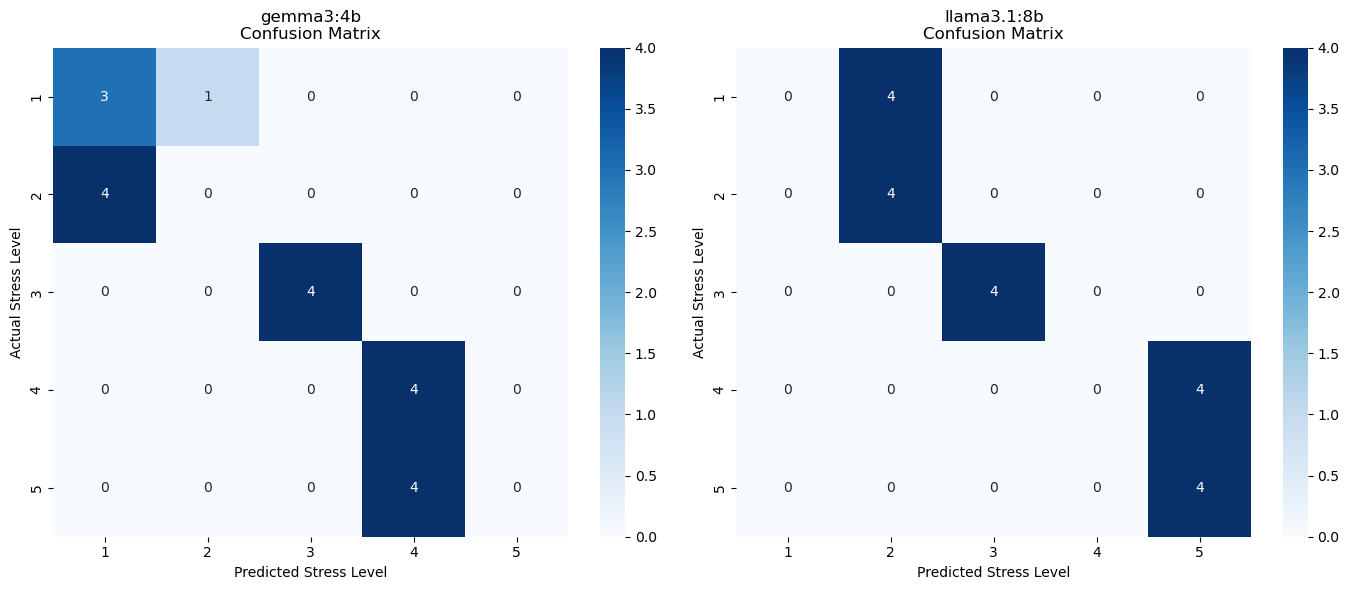

In [15]:
results = run_evaluation(num_samples=20)